# Comparison of miniMie and miepython results for a typical gold nanoparticle case



Here, we make a simple comparison between two numerical recipes for calculating Mie spectra: Bohren & Huffman, as used by miniMie, and Wiscombe, as used by the nice [miepython](https://github.com/scottprahl/miepython) library.

First, the traditional imports.

In [1]:
import numpy as np
from numpy import pi, log
import matplotlib.pyplot as plt

In [2]:
from miniMie import Mie_spectrum, JC_gold

We will take a gold nanoparticle of 50 nm diameter (radius 25 nm).

In [3]:
d_nm = 50.
r_nm = d_nm/2.0
mat = JC_gold()

We define a range of spectroscopic wavelengths for which we desire the cross sections. Here, we cover 380 ... 1000 nm.

In [4]:
wavelens = np.linspace(380., 1000., 1000)

`Mie_spectrum` returns the Mie extinction and scattering cross sections for these wavelengths. They are designated as $Q_\textrm{ext}$ and $Q_\textrm{sca}$, respectively, and are the optical cross sections relative to the geometrical cross sections.

## Standard miniMie calculation, using Bohren & Huffman

By default, `Mie_spectrum` uses the Python version of the Mätzler code that is integrated in miniMie. The Mätzler code is based on Bohren & Huffman.

In [5]:
(Q_ext, Q_sca) = Mie_spectrum(wavelens, 
                              d_nm, 
                              material = mat,
                              n_medium = 1.33)

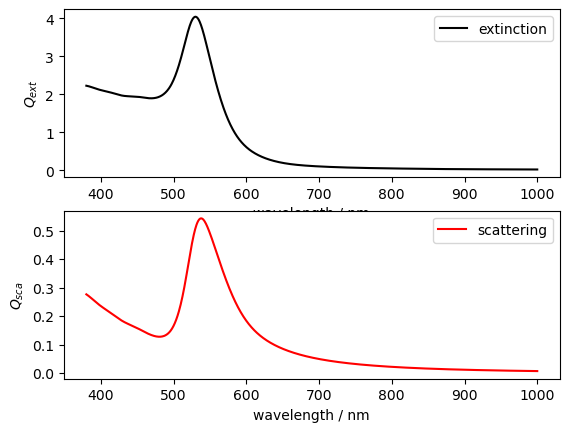

In [6]:
plt.figure()
plt.subplot(211)
plt.plot(wavelens, Q_ext, 'k-', label='extinction')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{ext}$')
plt.legend()
plt.subplot(212)
plt.plot(wavelens, Q_sca, 'r-', label='scattering')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{sca}$')
plt.legend()

## The same calculation, using Wiscombe via the external miepython module

miniMie's `Mie_spectrum` can also use the computation engine from [miepython](https://github.com/scottprahl/miepython) provided that this Python library is present in the environment. miepython uses Wiscombe's algorithm which is more robust in more extreme cases.

In [7]:
(Q_ext_2, Q_sca_2) = Mie_spectrum(wavelens, 
                                  d_nm, 
                                  material = mat,
                                  n_medium = 1.33,
                                  ext_engine = 'miepython')

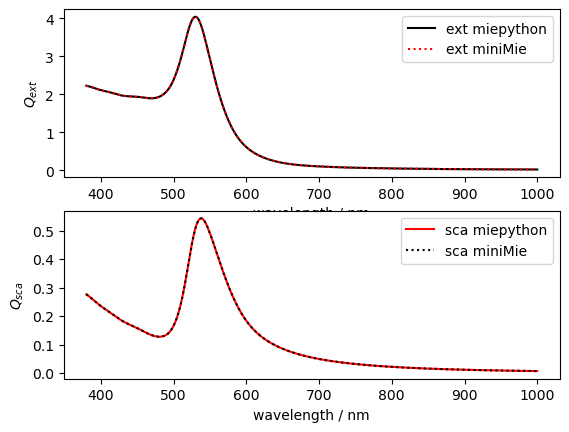

In [8]:
plt.figure()
plt.subplot(211)
plt.plot(wavelens, Q_ext_2, 'k-', label='ext miepython')
plt.plot(wavelens, Q_ext, 'r:', label='ext miniMie')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{ext}$')
plt.legend()
plt.subplot(212)
plt.plot(wavelens, Q_sca_2, 'r-', label='sca miepython')
plt.plot(wavelens, Q_sca, 'k:', label='sca miniMie')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{sca}$')
plt.legend()

The results from miniMie and miepython are visually identical, and they should be, of course. Very reassuring!

Let's see if there are minor differences, by calculating the relative differences between spectra from the two methods.

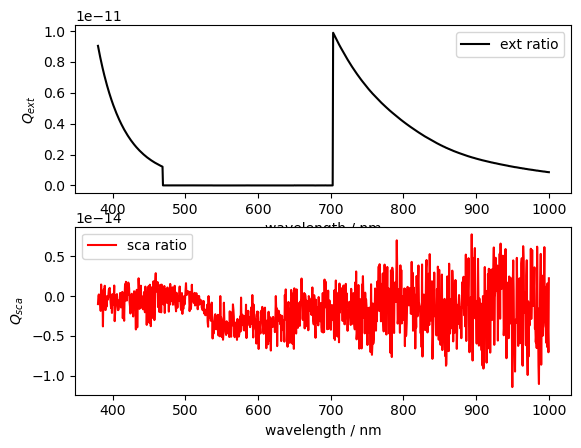

In [9]:
plt.figure()
plt.subplot(211)
plt.plot(wavelens, (Q_ext-Q_ext_2)/Q_ext, 'k-', label='ext ratio')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{ext}$')
plt.legend()
plt.subplot(212)
plt.plot(wavelens, (Q_sca-Q_sca_2)/Q_sca, 'r-', label='sca ratio')
plt.xlabel('wavelength / nm')
plt.ylabel('$Q_{sca}$')
plt.legend()

Well, yes, we do see very minor relative differences: less than $10^{-11}$ in extinction, and less than $10^{-14}$ in scattering. 

One of the two methods (or both) seems to 'switch' depending on wavelength in the extinction calculation. Remember that this is a very extreme zoom, so the effect is really, really small.

The difference between the scattering spectra looks "noisy". Very cute! Remember that this is an even more extreme zoom, so the difference is really, really, really small.
